# Scientific Machine Learning HW 1: Support Vector Machines and Phase Transition of Ising Model

In [1]:
import numpy as np

try:
    from sklearnex import patch_sklearn
    patch_sklearn()
except:
    print("Intel® Extension for Scikit-learn* not installed.")

from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

c:\Users\danie\miniconda3\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Prepare Data

In [2]:
# The data consists of 16 * 10000 samples taken in T = {0.25, 0.5, ..., 4.}.
# Each sample consists of spins in a 40 * 40 lattice.
temps = np.repeat(np.linspace(0.25, 4., 16), 10000)
T_c = 2 / np.log(1 + np.sqrt(2))
# The first 9 * 10000 samples are ordered (label 1).
# The remaining 7 * 10000 samples are disordered (label 0).
data_file_name = "Ising2DFM_reSample_L40_T=All.pkl"
label_file_name = "Ising2DFM_reSample_L40_T=All_labels.pkl"

with open(data_file_name, "rb") as pickle_file:
    data = pickle.load(pickle_file)
data = np.unpackbits(data).reshape(-1, 1600).astype(int)
data[np.where(data==0)] = -1

# Label is 1 for ordered states and 0 for disordered states
with open(label_file_name, "rb") as pickle_file:
    labels = pickle.load(pickle_file)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (160000, 1600)
Labels: [0 1]


In [3]:
# 75% train, 25% test
data_train, data_test, labels_train, labels_test, temps_train, temps_test = train_test_split(data, labels, temps, stratify = temps)

In [4]:
scorers = ["accuracy", "precision", "recall", "f1"]

## Logistic Regression

In [5]:
lr_models = [LogisticRegressionCV(l1_ratios = (0,), scoring = scorer, max_iter = 1000,
                                  cv = StratifiedKFold(n_splits = 5, shuffle = True), n_jobs = -2,
                                  use_legacy_attributes = False)
             for scorer in scorers]

In [ ]:
# Takes about 3 minutes on my laptop
for lr_model in tqdm(lr_models):
    lr_model.fit(data_train, labels_train)

  0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
lr_scores = np.zeros(len(scorers))
lr_scores_temps = np.zeros((len(scorers), 16))

for i, lr_model in enumerate(tqdm(lr_models)):
    print("Metric: {}".format(lr_model.scoring))
    lr_scores[i] = lr_model.score(data_test, labels_test)
    print("Overall {}: {:.4f}".format(lr_model.scoring, lr_scores[i]))
    for j in range(16):
        temp = 0.25 * (j + 1)
        if lr_model.scoring == "recall" and temp > T_c:
            # Recall is ill-defined when there are no positive samples
            lr_scores_temps[i, j] = np.nan
        else:
            lr_scores_temps[i, j] = lr_model.score(data_test[temps_test == temp], labels_test[temps_test == temp])
    if lr_model.scoring == "accuracy":
        print("Best {}: {:.4f} at T = {}".format(lr_model.scoring, np.max(lr_scores_temps[i]),
                                                 0.25 * (np.argmax(lr_scores_temps[i]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(lr_model.scoring, np.min(lr_scores_temps[i]),
                                                  0.25 * (np.argmin(lr_scores_temps[i]) + 1)))
    else:
        # Precision and F1 are trivially 0 when there are no positive samples
        print("Best {}: {:.4f} at T = {}".format(lr_model.scoring, np.max(lr_scores_temps[i, :9]),
                                                 0.25 * (np.argmax(lr_scores_temps[i, :9]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(lr_model.scoring, np.min(lr_scores_temps[i, :9]),
                                                  0.25 * (np.argmin(lr_scores_temps[i, :9]) + 1)))
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.6527
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.1972 at T = 2.5

Metric: precision
Overall precision: 0.6211
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.9972
Best recall: 1.0000 at T = 0.25
Worst recall: 0.9764 at T = 2.25

Metric: f1
Overall f1: 0.7599
Best f1: 1.0000 at T = 0.25
Worst f1: 0.9270 at T = 2.25



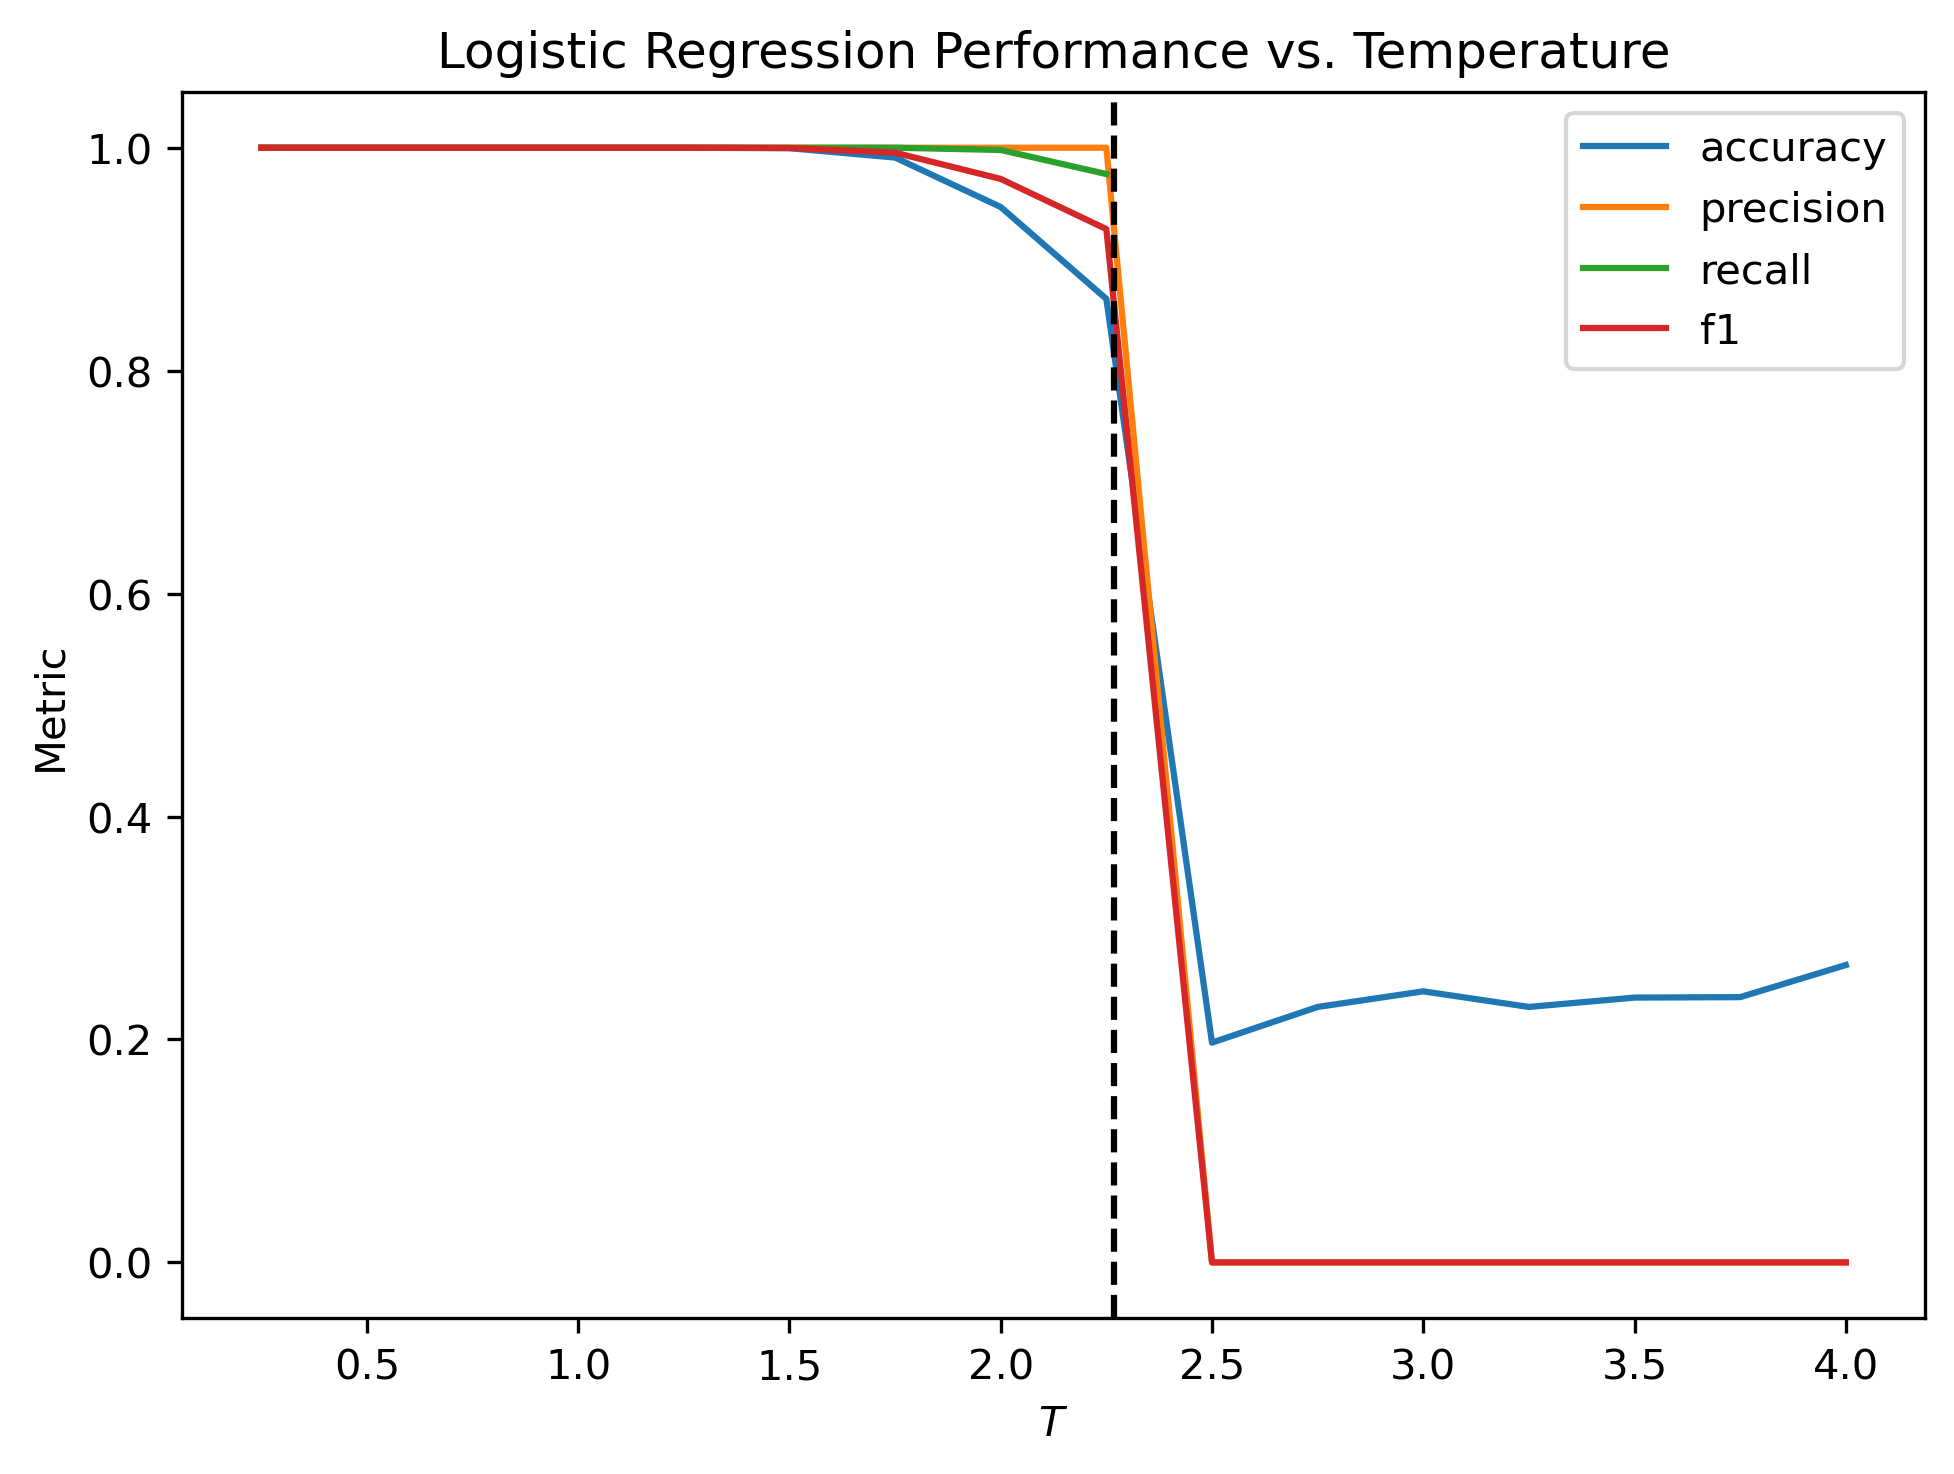

In [8]:
plt.figure(dpi = 300, layout = "constrained")
for i, scorer in enumerate(scorers):
    plt.plot(np.linspace(0.25, 4., 16), lr_scores_temps[i], label = scorer)
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Logistic Regression Performance vs. Temperature")
plt.legend()
plt.savefig("logistic.pdf")

## SVM

In [16]:
p_grid = {
    "svc__kernel": ["linear", "rbf"],
    "svc__C": [0.01, 0.1, 1, 10, 100]
}
svm = make_pipeline(StandardScaler(), SVC(), verbose = True) # Each fit takes about 43 seconds on my laptop

In [17]:
svm_models = [GridSearchCV(estimator = svm, param_grid = p_grid, cv = StratifiedKFold(n_splits = 5, shuffle = True),
                           scoring = scorer, n_jobs = -2, verbose = 2)
              for scorer in scorers]

In [18]:
# 4 loops = about 2.5 hours
for svm_model in tqdm(svm_models):
    # 50 fits * 43 seconds = about 36 minutes
    svm_model.fit(data_train, labels_train)
    print("Best parameters for {}:".format(svm_model.scoring))
    print(svm_model.best_params_)
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [ ]:
svm_scores = np.zeros(len(scorers))
svm_scores_temps = np.zeros((len(scorers), 16))

for i, svm_model in enumerate(tqdm(svm_models)):
    print("Metric: {}".format(svm_model.scoring))
    svm_scores[i] = svm_model.score(data_test, labels_test)
    print("Overall {}: {:.4f}".format(svm_model.scoring, svm_scores[i]))
    for j in range(16):
        temp = 0.25 * (j + 1)
        if svm_model.scoring == "recall" and temp > T_c:
            # Recall is ill-defined when there are no positive samples
            svm_scores_temps[i, j] = np.nan
        else:
            svm_scores_temps[i, j] = svm_model.score(data_test[temps_test == temp], labels_test[temps_test == temp])
    if svm_model.scoring == "accuracy":
        print("Best {}: {:.4f} at T = {}".format(svm_model.scoring, np.max(svm_scores_temps[i]),
                                                 0.25 * (np.argmax(svm_scores_temps[i]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(svm_model.scoring, np.min(svm_scores_temps[i]),
                                                  0.25 * (np.argmin(svm_scores_temps[i]) + 1)))
    else:
        # Precision and F1 are trivially 0 when there are no positive samples
        print("Best {}: {:.4f} at T = {}".format(svm_model.scoring, np.max(svm_scores_temps[i, :9]),
                                                 0.25 * (np.argmax(svm_scores_temps[i, :9]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(svm_model.scoring, np.min(svm_scores_temps[i, :9]),
                                                  0.25 * (np.argmin(svm_scores_temps[i, :9]) + 1)))
    print()

In [ ]:
plt.figure(dpi = 300, layout = "constrained")
for i, scorer in enumerate(scorers):
    plt.plot(np.linspace(0.25, 4., 16), lr_scores_temps[i], label = scorer)
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Support Vector Machine Performance vs. Temperature")
plt.legend()
plt.savefig("svm.pdf")